![display relevant image here](path/url/to/image)
- Banner/header image

# Financial Loan Risk Prediction

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

Financial institutions traditionally rely on loan officers to manually assess loan applications by reviewing factors such as income, employment status, credit history, existing debts, and other financial information before making approval decisions. Although this process allows for professional judgment, it is often time-consuming, inconsistent, and susceptible to human error or bias, particularly when processing a large number of applications. 

The key stakeholders include:
* loan applicants - who expect fair and timely decisions 
* loan officers - who require reliable decision-support tools
* bank management - whose goal is to maximize profitability while minimizing financial losses
* the risk management team - which focuses on reducing loan defaults. 

Since the objective is to predict whether an applicant should be approved or rejected, this is a classification problem rather than a regression problem because the target variable consists of discrete categories instead of continuous values. From a business perspective, the most costly error is approving a high-risk customer who later defaults on the loan (false positive), while rejecting a creditworthy customer (false negative) mainly results in lost business opportunities. Therefore, the model should prioritize minimizing false positives to reduce financial risk.

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


The primary objective of this project is to develop a machine learning classification model capable of accurately predicting whether a loan applicant is likely to be a low-risk or high-risk borrower, thereby supporting faster and more consistent loan approval decisions. Since approving a high-risk applicant has greater financial consequences than rejecting a creditworthy one, the model will prioritize minimizing false positives by optimizing precision while also considering recall and the F1-score to maintain a balance between identifying risky applicants and avoiding unnecessary loan rejections. Overall model performance will also be assessed using accuracy and the ROC-AUC score to evaluate the model’s ability to distinguish between the two classes across different decision thresholds. A baseline model will first be established before comparing multiple machine learning algorithms, with the final model selected based on its ability to achieve strong predictive performance while minimizing business risk and maintaining good generalization on unseen data.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [64]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)

In [80]:
#load the datastet
df = pd.read_csv("Loan.csv")

#display the first five rows
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [83]:
# Separate features and target
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

In [84]:
#check shape
X.shape

(20000, 35)

After separating the target variable, the feature matrix (X) contains 20,000 observations and 35 predictor variables. This provides sufficient data for exploratory analysis and subsequent model development.

In [85]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

In [89]:
# Summary statistics
X.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ApplicationDate,20000,20000,2018-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000.0,NaN,NaN,NaN,59161.47355,40350.845168,15000.0,31679.0,48566.0,74391.0,485341.0
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,20000,5,Bachelor,6054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,20000,4,Married,10041,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observation: The summary statistics show that the dataset contains both numerical and categorical features. Numerical variables exhibit varying ranges and distributions, while categorical variables such as EmploymentStatus, EducationLevel, MaritalStatus, and LoanPurpose contain a limited number of unique categories. These summaries provide an initial understanding of the dataset and highlight variables that may require preprocessing or further exploration.

In [90]:
# Target distribution
y.value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [91]:
# Target proportions
y.value_counts(normalize=True) * 100

LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64

Observation: Approximately 76.1% of loan applications were approved, while 23.9% were rejected. This indicates a moderate class imbalance, which should be considered during model evaluation.

In [92]:
#check for missing values
X.isna().sum().sort_values(ascending=False)

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

Observation: No missing values were detected in the feature set. This indicates that the dataset has already been cleaned and is ready for preprocessing. Although no imputation is required for this dataset, a preprocessing pipeline will still be used to ensure a consistent and reusable machine learning workflow.

In [87]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

There are no duplicate records

In [93]:
# Categorize features by data type
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numerical_cols))
print(numerical_cols)

print("\nCategorical features:", len(categorical_cols))
print(categorical_cols)

Numerical features: 29
Index(['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
       'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'],
      dtype='str')

Categorical features: 6
Index(['ApplicationDate', 'EmploymentStatus', 'EducationLevel',
       'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose'],
      dtype='str')


Observation:
The dataset contains *29 numerical features* and *6 categorical features*.

Most object variables represent genuine categorical data and will later be encoded within the preprocessing pipeline. However, ApplicationDate is a temporal feature rather than a categorical variable and may require feature engineering or exclusion before model training.

In [94]:
# Check the number of unique values in each categorical feature
for col in categorical_cols:
    print(f"\n{col}")
    print(X[col].value_counts())


ApplicationDate
ApplicationDate
2018-01-01    1
2018-01-02    1
2018-01-03    1
2018-01-04    1
2018-01-05    1
             ..
2072-09-29    1
2072-09-30    1
2072-10-01    1
2072-10-02    1
2072-10-03    1
Name: count, Length: 20000, dtype: int64

EmploymentStatus
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     10041
Single       6078
Divorced     2882
Widowed       999
Name: count, dtype: int64

HomeOwnershipStatus
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64

LoanPurpose
LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


Observation: Most categorical variables have low cardinality and are suitable for One-Hot Encoding during preprocessing. ApplicationDate, however, contains a unique value for every record (20,000 unique dates), making it a high-cardinality temporal feature. Instead of encoding it, the variable will be excluded from the model to avoid unnecessarily increasing the feature space.

In [ ]:
# Drop ApplicationDate
X = X.drop("ApplicationDate", axis=1)

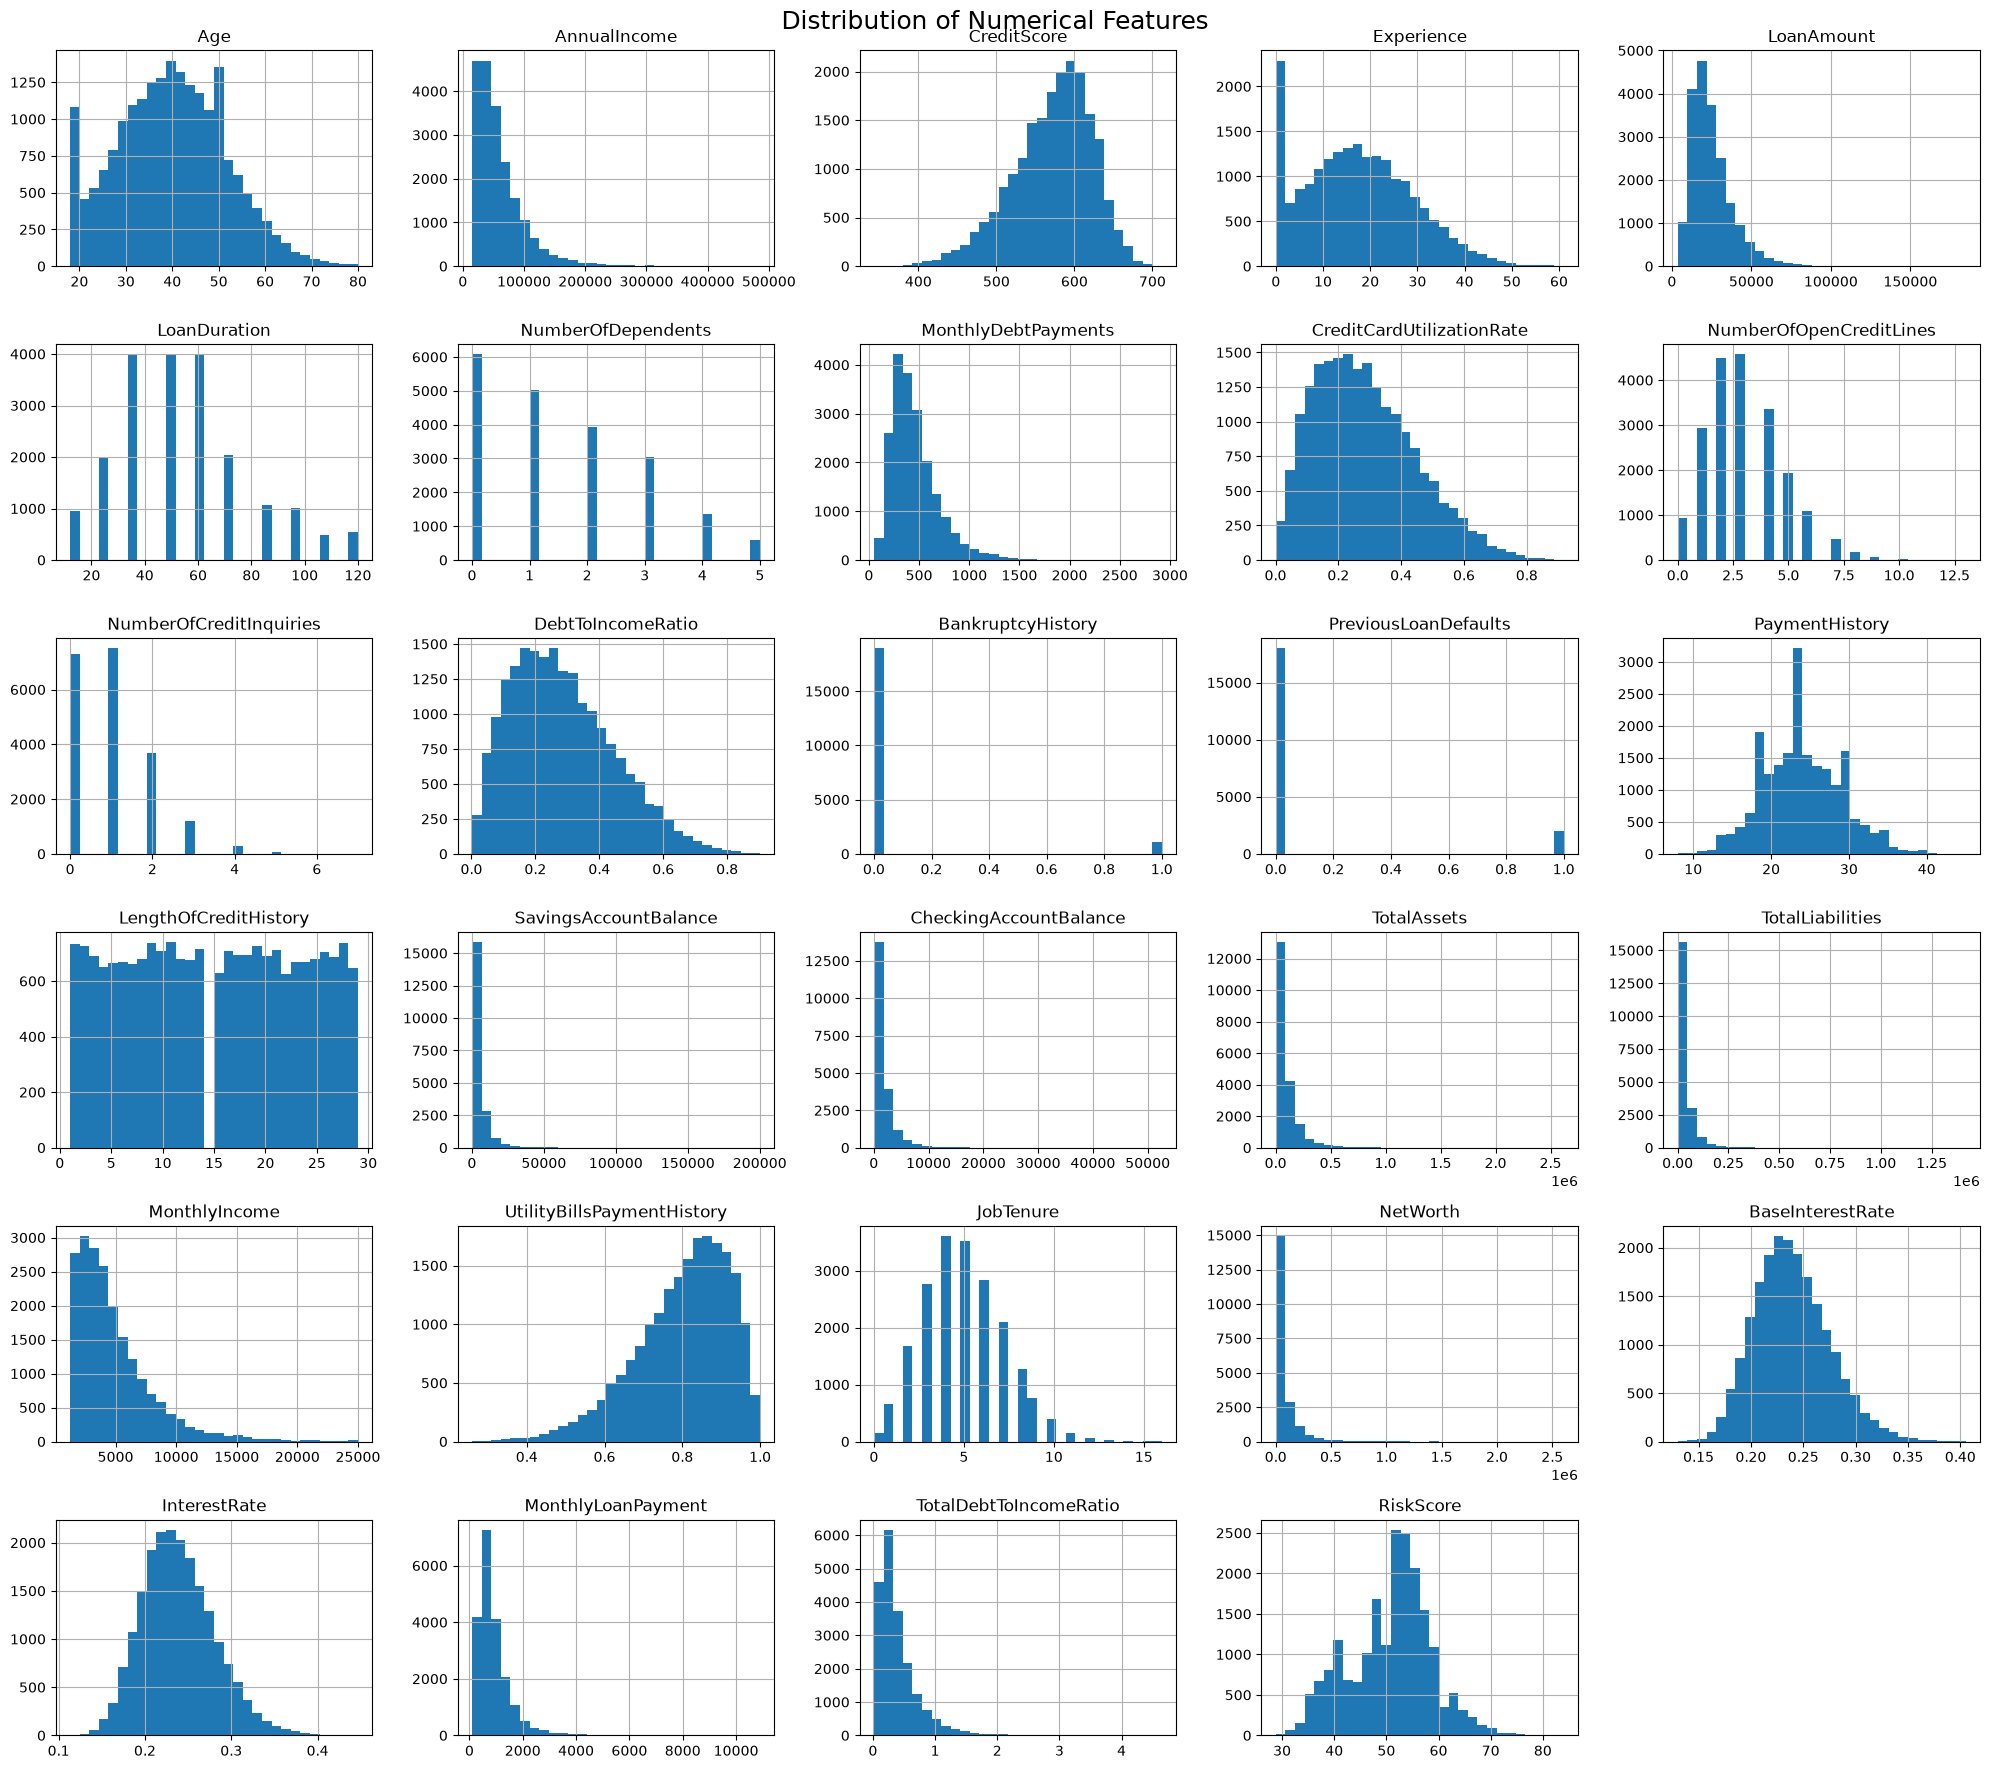

In [ ]:
#Visualization
# 1. Distribution of numerical features
X[numerical_cols].hist(figsize=(20,18), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

Observation: Most numerical variables exhibit different distributions. Some variables appear approximately normally distributed, while others are positively skewed with long right tails. Features such as income, loan amount, assets, and net worth display larger ranges, suggesting that feature scaling may be beneficial during preprocessing.

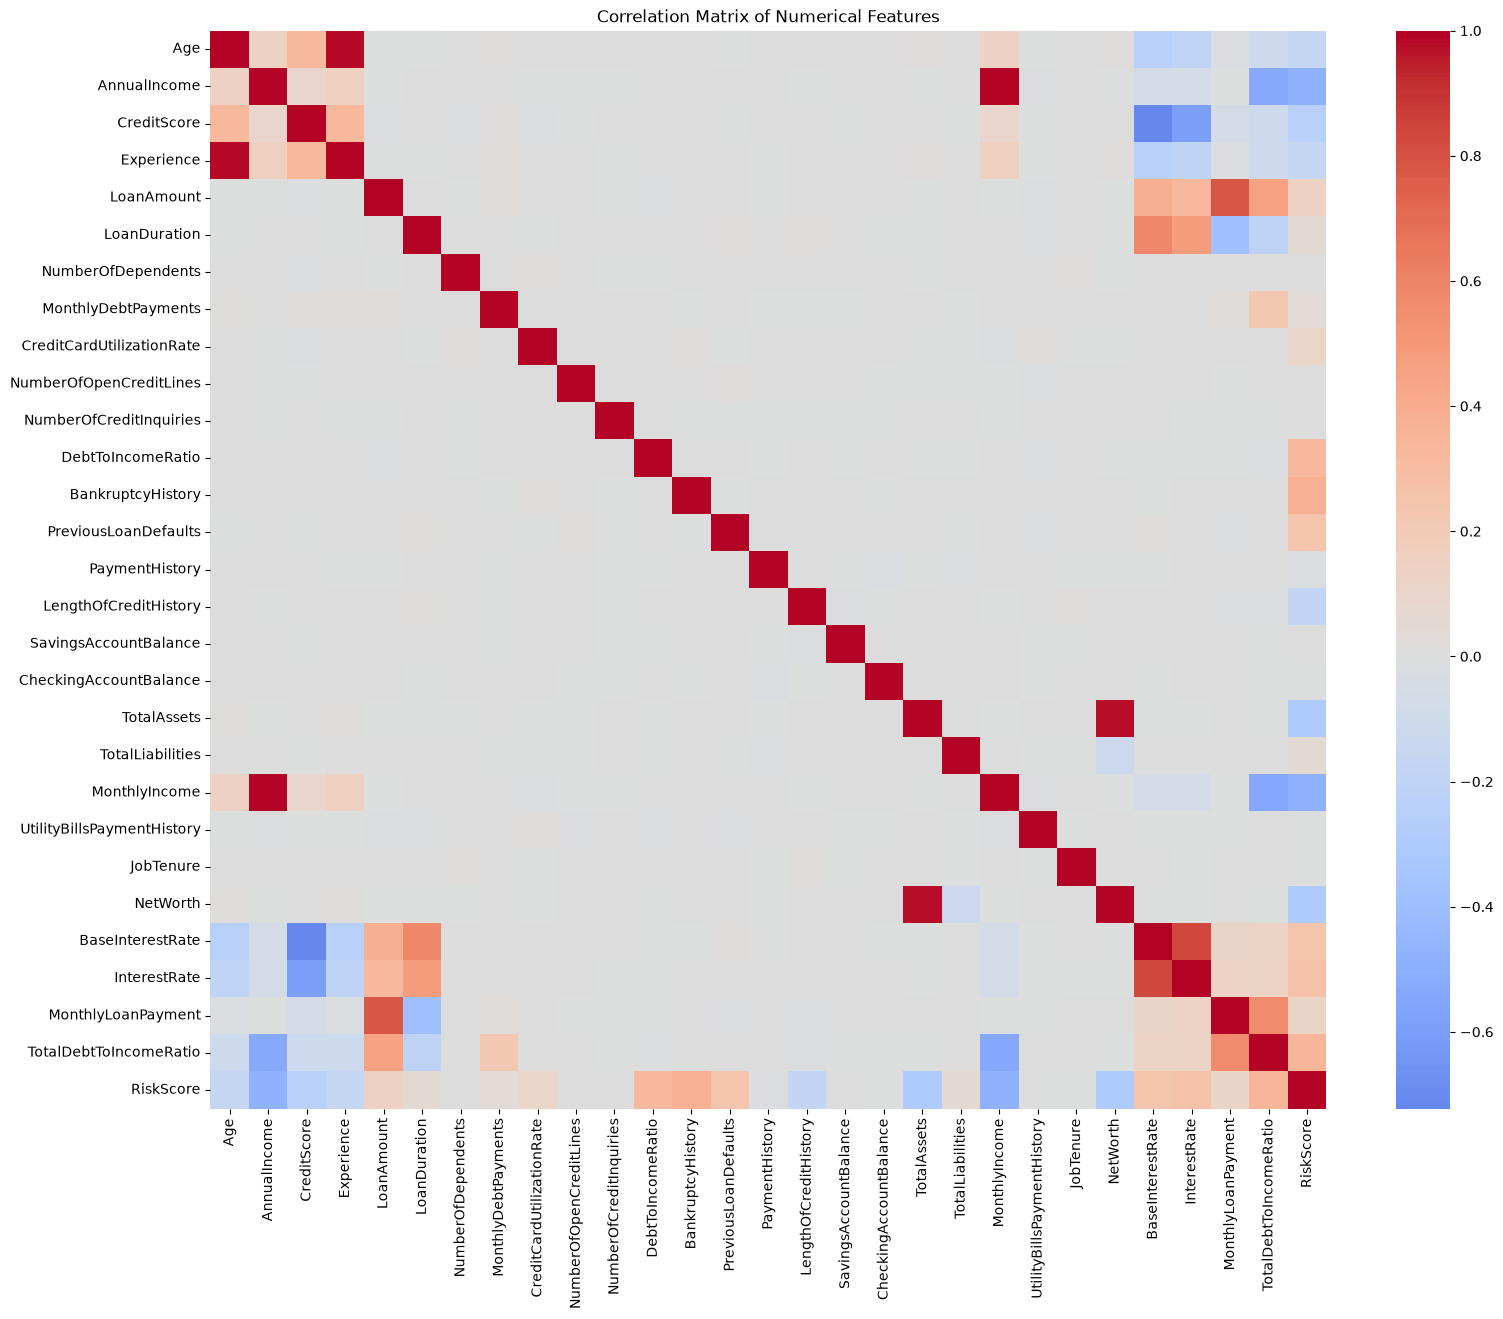

In [98]:
plt.figure(figsize=(18,14))

sns.heatmap(
    X[numerical_cols].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

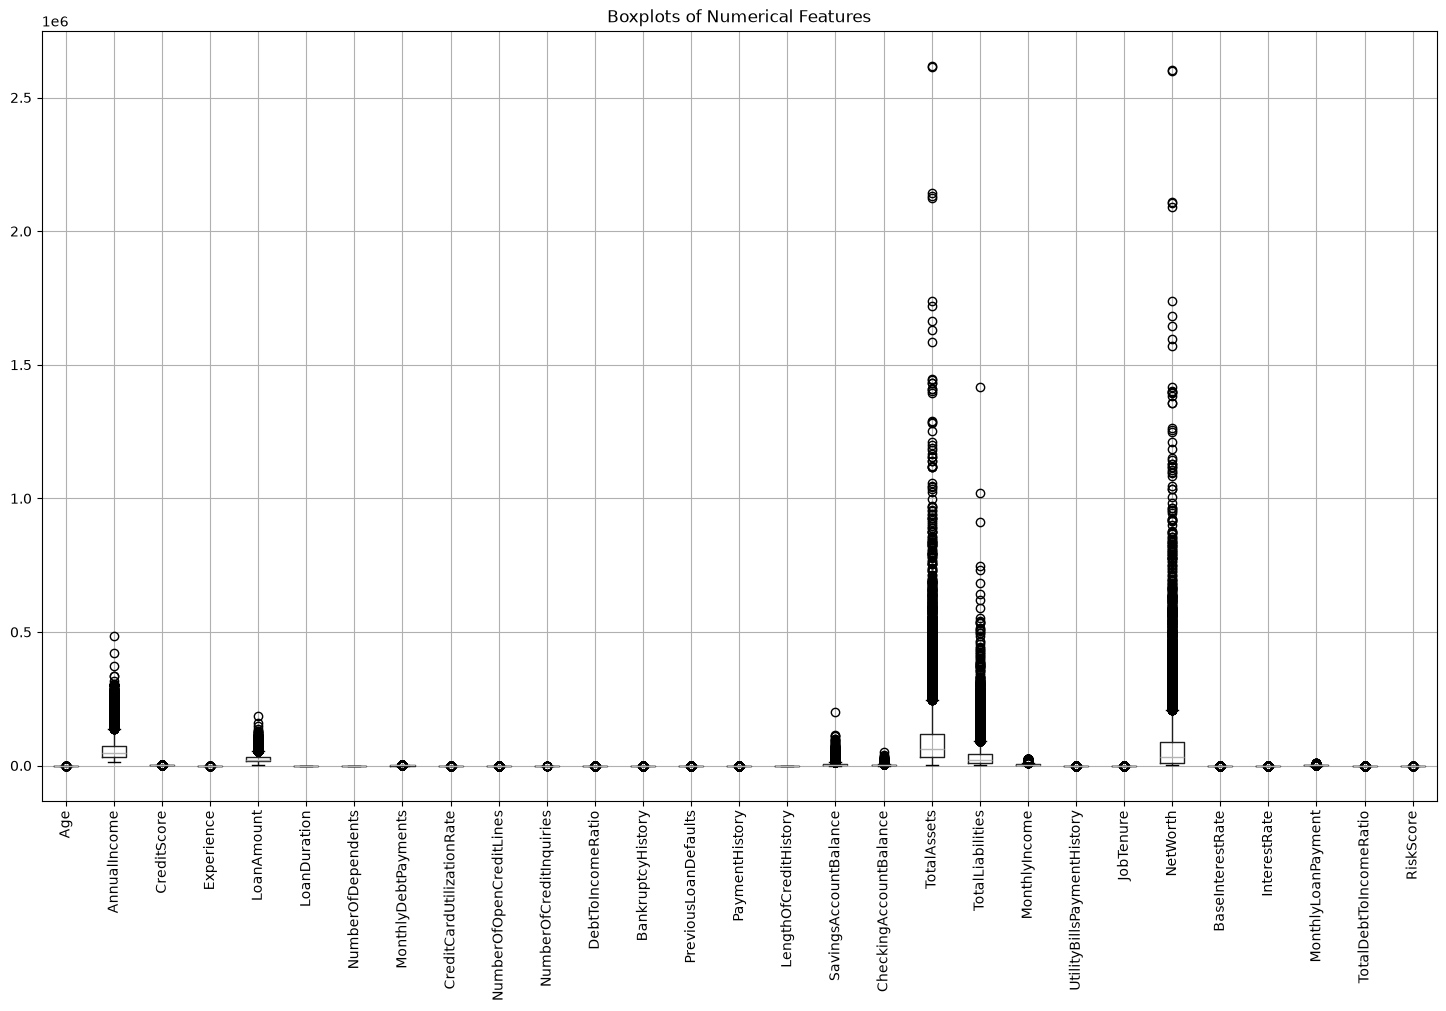

In [99]:
plt.figure(figsize=(18,10))

X[numerical_cols].boxplot(rot=90)

plt.title("Boxplots of Numerical Features")

plt.show()

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [72]:
# Data Prep Code Here - Create New Cells As Needed
None

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [73]:
#  Modeling Code Here - Create New Cells as Needed
None

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements